In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import setup_plotting, switch_cwd_to_root

switch_cwd_to_root()

figure_dir = "figures/revision/supplement-extra"
setup_plotting(figure_dir, display_dpi=200, save_dpi=300)

import os

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc

from spatial_tcr.spatial import (
    fill_annotations,
    spatial_expansion,
    spatial_sample_split,
)

## Load data

In [4]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.1-kidney_tcr_clonal_clusters.h5ad"
adata = sc.read_h5ad(path)

# remove control samples
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [5]:
adata.obs["glom_annot"].value_counts()

glom_annot
glom_145    387
glom_364    373
glom_561    306
glom_555    296
glom_102    285
           ... 
glom_294     30
glom_613     30
glom_398     27
glom_427     27
glom_279     26
Name: count, Length: 140, dtype: int64

## Annotate Periglom. areas.

In [6]:
spatial_sample_split(adata, sample_key="sample", out_key="spatial")

/tmp/ipykernel_2413006/4076558491.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="sample", spot_size=10)


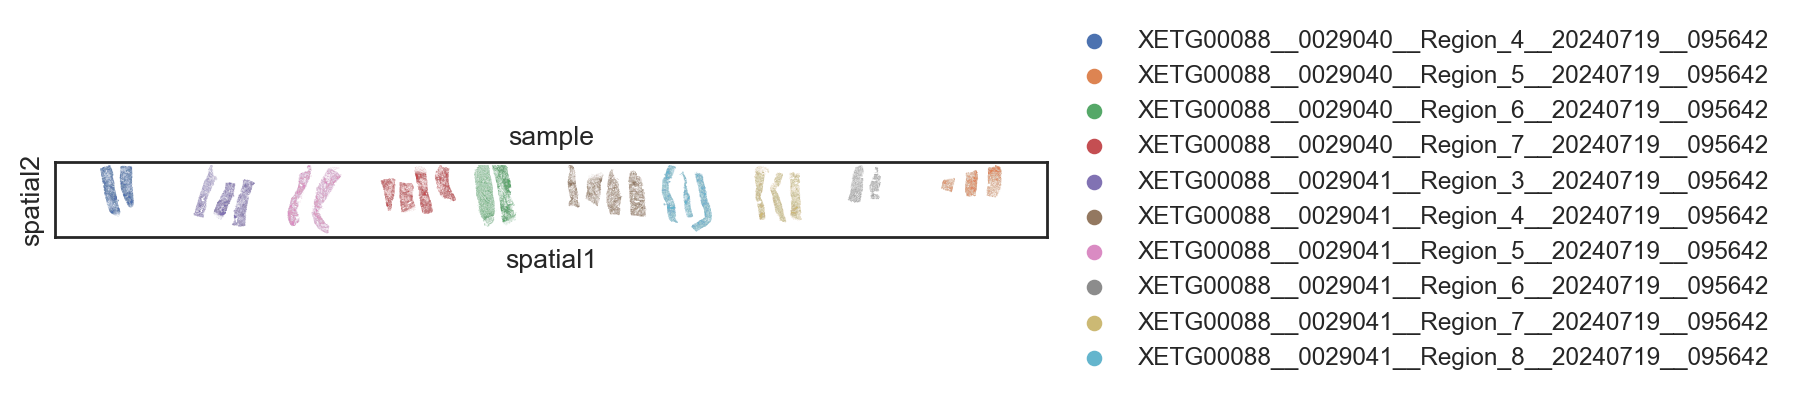

In [7]:
sc.pl.spatial(adata, color="sample", spot_size=10)

In [8]:
fill_annotations(
    adata,
    obs_key="glom_annot",
    out_key="glom_annot_filled",
    sample_key="sample",
    spatial_key="spatial",
)

Filling annotations:   0%|          | 0/140 [00:00<?, ?it/s]

/tmp/ipykernel_2413006/3290686077.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color="glom_annot_filled", spot_size=10)
/home/dschaub/.uv-local/venvs/xenium-tcr/lib/python3.13/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


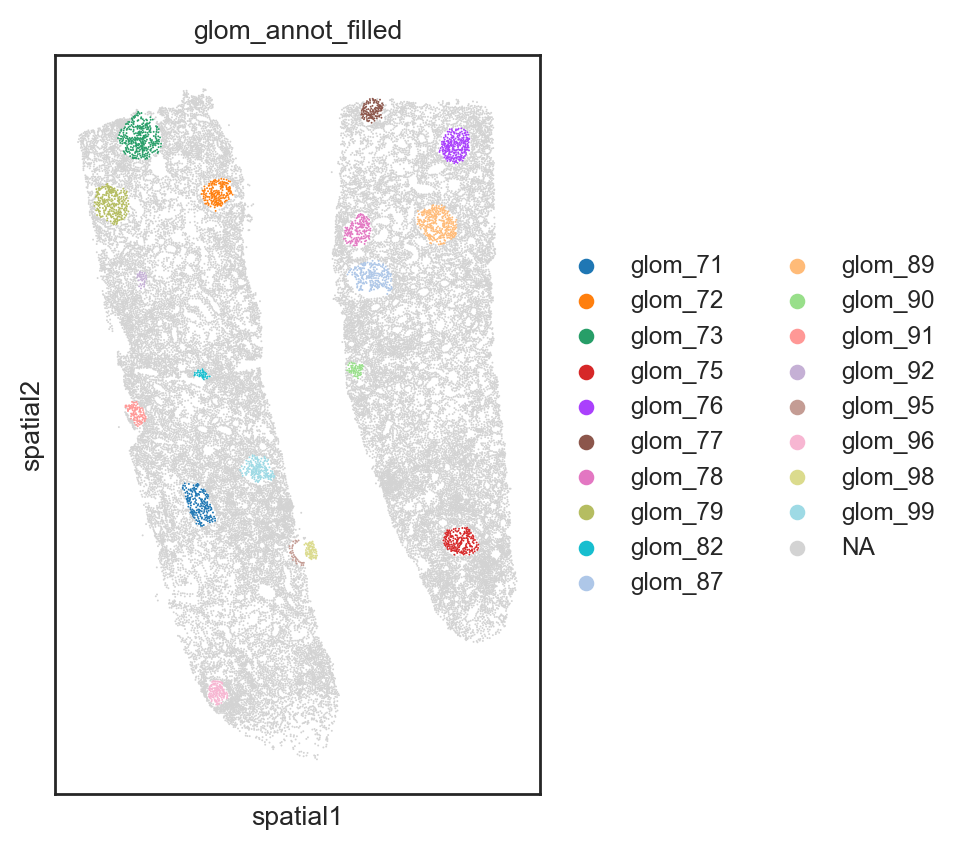

In [9]:
ad_sub = adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]]
sc.pl.spatial(ad_sub, color="glom_annot_filled", spot_size=10)

In [10]:
spatial_expansion(
    adata,
    obs_key="glom_annot_filled",
    out_key="glom_annot_filled_expanded",
    expansion=100,
    sample_key="sample",
    spatial_key="spatial",
)

  0%|          | 0/140 [00:00<?, ?it/s]

/tmp/ipykernel_2413006/1676547999.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color="glom_annot_filled", spot_size=10, title="Glom. Annotation")
/home/dschaub/.uv-local/venvs/xenium-tcr/lib/python3.13/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


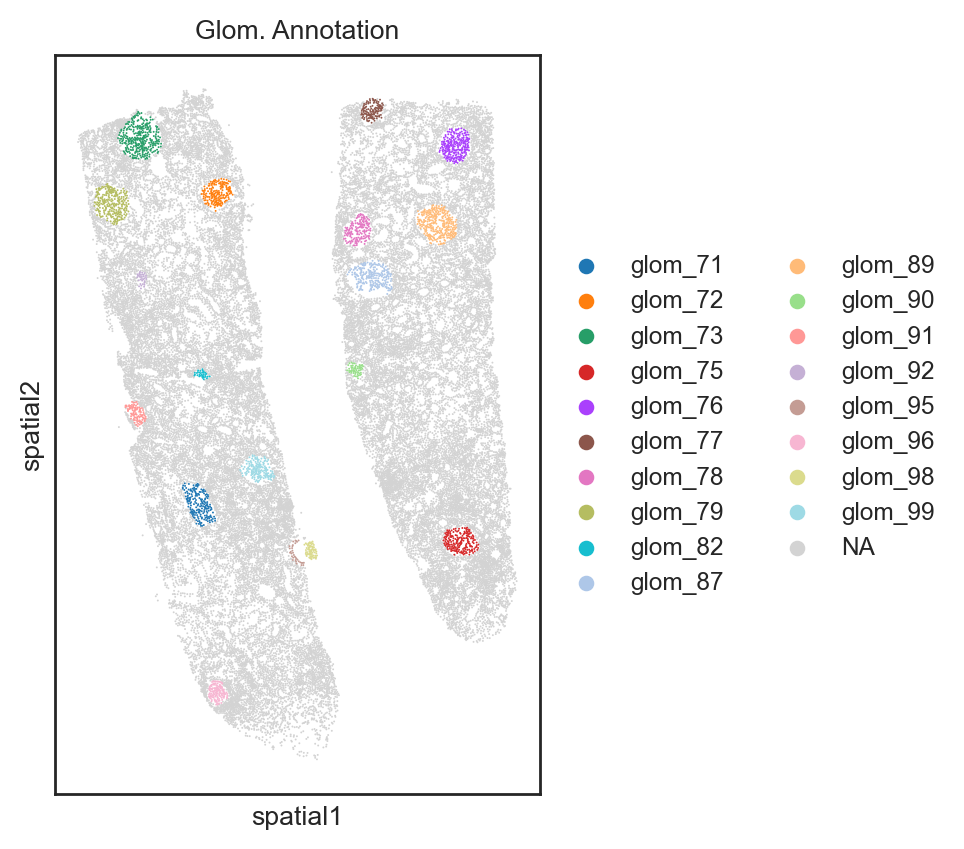

/tmp/ipykernel_2413006/1676547999.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color="glom_annot_filled_expanded", spot_size=10)


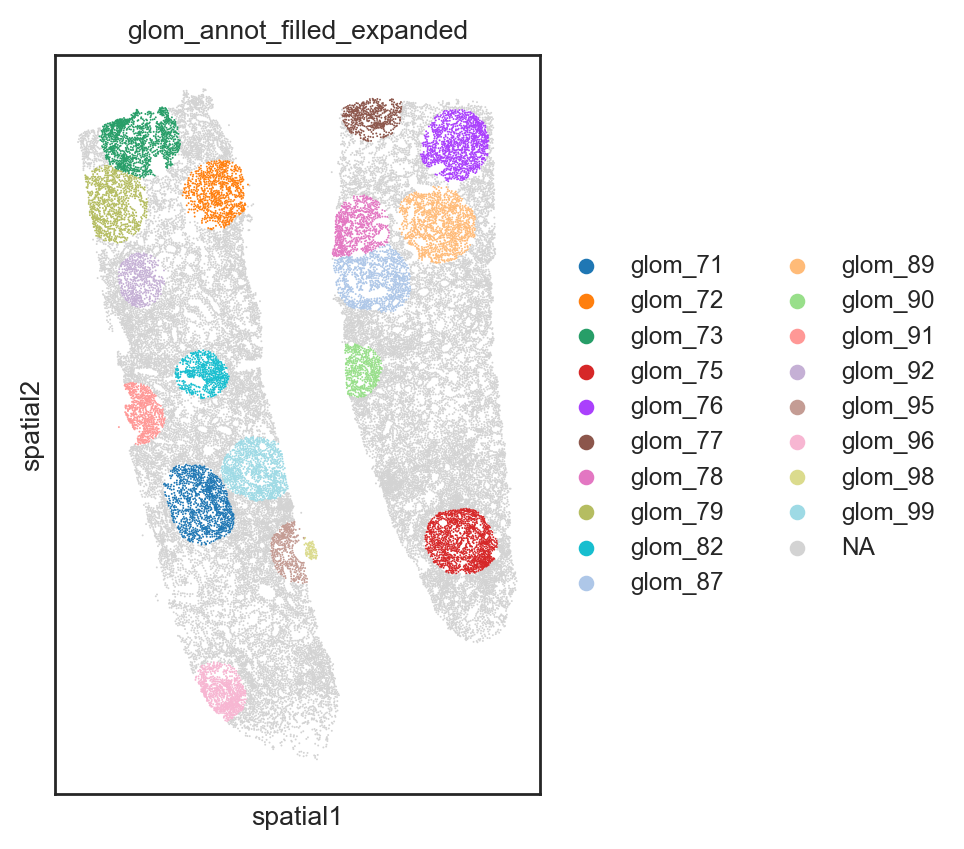

In [11]:
ad_sub = adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]]
sc.pl.spatial(ad_sub, color="glom_annot_filled", spot_size=10, title="Glom. Annotation")
sc.pl.spatial(ad_sub, color="glom_annot_filled_expanded", spot_size=10)

/tmp/ipykernel_2413006/1039067079.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(
/home/dschaub/.uv-local/venvs/xenium-tcr/lib/python3.13/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


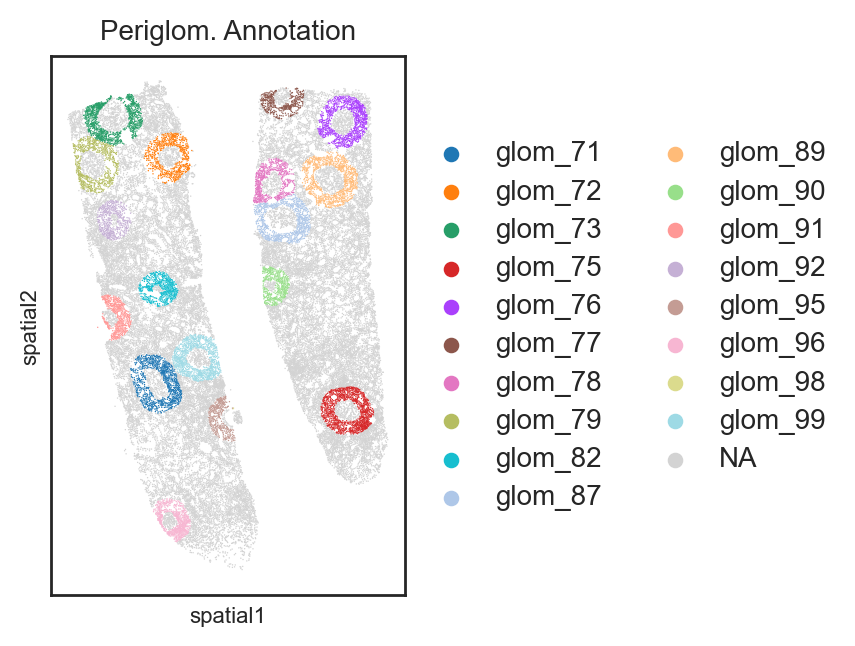

In [25]:
adata.obs["peri_glom_annot"] = adata.obs["glom_annot_filled_expanded"].copy()
adata.obs.loc[adata.obs["glom_annot_filled"].notna(), "peri_glom_annot"] = pd.NA


ad_sub = adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]]

import matplotlib as mpl

mpl.rcParams["figure.figsize"] = (3.5, 3.5)

fig = sc.pl.spatial(
    ad_sub,
    color="peri_glom_annot",
    spot_size=10,
    title="Periglom. Annotation",
    return_fig=True,
    show=False,
)
ax = fig.axes[0]

# x/y label fontsize
ax.set_xlabel(ax.get_xlabel(), fontsize=8)
ax.set_ylabel(ax.get_ylabel(), fontsize=8)

# title fontsize
ax.set_title(ax.get_title(), fontsize=10)

# legend fontsize (if present)
leg = ax.get_legend()
if leg is not None:
    for t in leg.get_texts():
        t.set_fontsize(10)
    if leg.get_title() is not None:
        leg.get_title().set_fontsize(10)

fig.savefig(
    os.path.join(figure_dir, "peri_glom_annot.pdf"), bbox_inches="tight", dpi=300
)

/tmp/ipykernel_2413006/3556954819.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


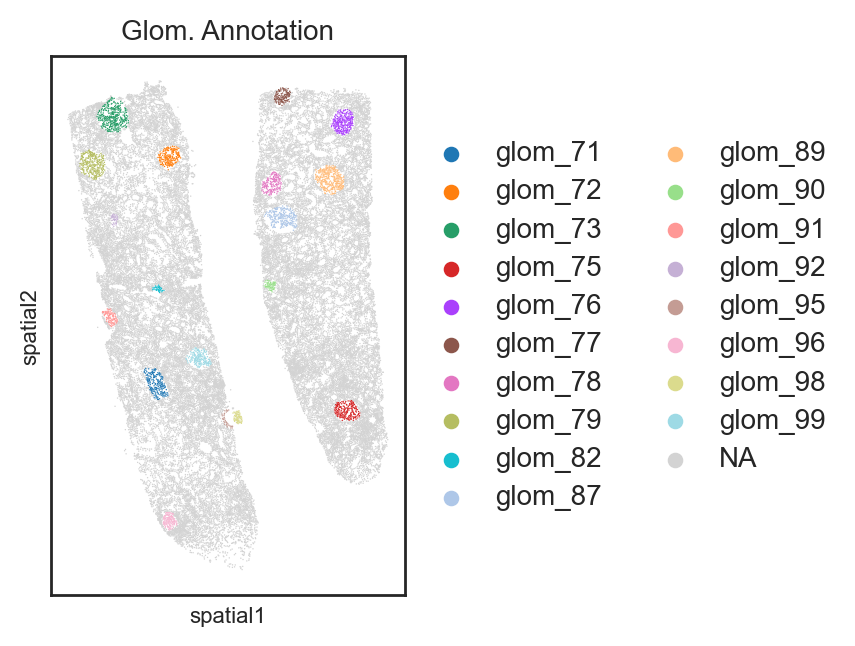

In [24]:
mpl.rcParams["figure.figsize"] = (3.5, 3.5)
fig = sc.pl.spatial(
    ad_sub,
    color="glom_annot_filled",
    spot_size=10,
    title="Glom. Annotation",
    return_fig=True,
    show=False,
)
ax = fig.axes[0]

# x/y label fontsize
ax.set_xlabel(ax.get_xlabel(), fontsize=8)
ax.set_ylabel(ax.get_ylabel(), fontsize=8)

# title fontsize
ax.set_title(ax.get_title(), fontsize=10)

# legend fontsize (if present)
leg = ax.get_legend()
if leg is not None:
    for t in leg.get_texts():
        t.set_fontsize(10)
    if leg.get_title() is not None:
        leg.get_title().set_fontsize(10)
plt.savefig(os.path.join(figure_dir, "glom_annot_filled.pdf"))

In [11]:
adata.obs["in_peri_glom"] = adata.obs["peri_glom_annot"].notna()

## Save annotations

In [12]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.2-kidney_tcr_clonal_clusters_peri_glom_annot.h5ad"
adata.write_h5ad(path)

/home/dschaub/.uv-local/venvs/xenium-tcr/lib/python3.13/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
